In [1]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  StandardScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import os
import joblib



In [2]:
def pipeline():
    df=pd.read_csv("WineQT.csv")
    print(df.head())
    print(df.columns)
    print(f"Columns:",df.columns.to_list())
    print(df.shape)
    print(df.info())
    print(df.isnull().sum())

       #SHow which quality appears most
    plt.figure(figsize=(10,8))
    sns.countplot(x="quality",data=df)
    plt.title("Wine Quality Distribuition")
    plt.show()
    #show what affects quality most
    plt.figure(figsize=(8,5))
    sns.heatmap(df.corr(),annot=True,fmt=".2f",cmap='coolwarm')
    plt.title("Feature Correlation")
    plt.show()
    #Alcohol and quality relation
    plt.figure(figsize=(8,5))
    sns.boxplot(x='quality', y='alcohol', data=df)
    plt.title('Alcohol vs Quality')
    plt.show()
    
    #  all relationships at once
    sns.pairplot(df[['alcohol', 'pH', 
                    'volatile acidity', 
                    'citric acid', 'quality']], 
             hue='quality')
    plt.show()
    #outleri detection
    plt.figure(figsize=(15,6))
    sns.boxplot(data=df)
    plt.xticks(rotation=45)
    plt.title("Outliers Check")
    plt.show()  
    #removing id cause it have outlier
    
    df= df.drop('Id', axis=1)
    plt.figure(figsize=(15,6))
    sns.boxplot(data=df)
    plt.xticks(rotation=45)
    plt.title("Outliers Check Without Id")
    plt.show()

    #removing  outlier  from  total sufulr oxide
    Q1=df.quantile(0.25)
    Q3=df.quantile(0.75)
    IQR=Q3-Q1

    data_cleaned=df[~((df < (Q1- 1.5*IQR)) | (df > (Q3+1.5*IQR))).any(axis=1)]
    print("Before removing outliers:", df.shape)
    print("After removing outliers:", data_cleaned.shape)
    print("Rows removed:", df.shape[0] - data_cleaned.shape[0])
    #after removing outleier here
    plt.figure(figsize=(15,6))
    sns.boxplot(data=data_cleaned)
    plt.xticks(rotation=45)
    plt.title("After Removing Outliers")
    plt.show()


    X=data_cleaned.drop('quality',axis=1)
    Y=data_cleaned['quality']

    print("X_shape:",X.shape)
    print("Y_shape:",Y.shape)
    
    scaler=StandardScaler()
    X_scaled=scaler.fit_transform(X)
    

    print("Scaling DOne")
    X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y, 
    test_size=0.2,      # 80% train, 20% test
    random_state=42 )
    print("Train size:", X_train.shape)
    print("Test size:", X_test.shape)
    
    accuracy_rates = []

    for k in range(1, 30):
       knn = KNeighborsClassifier(n_neighbors=k)
       knn.fit(X_train, y_train)
       predictions = knn.predict(X_test)
       accuracy = accuracy_score(y_test, predictions)
       accuracy_rates.append(accuracy)

     # Plot accuracy
    plt.figure(figsize=(10,5))
    plt.plot(range(1, 30), accuracy_rates)
    plt.xlabel('K Value')
    plt.ylabel('Accuracy')
    plt.title('Finding Best K Value')
    plt.show()

    best_k = accuracy_rates.index(max(accuracy_rates)) + 1
    print(f"Best K value: {best_k}")
    print(f"Best Accuracy: {max(accuracy_rates):.2f}")

    knn = KNeighborsClassifier(n_neighbors=13)
    knn.fit(X_train, y_train)

    print("Model trained! ✅")
    print(classification_report(y_test, predictions))

    joblib.dump(knn,'my_trained_model.pkl')

    loaded_model=joblib.load('my_trained_model.pkl')
       


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

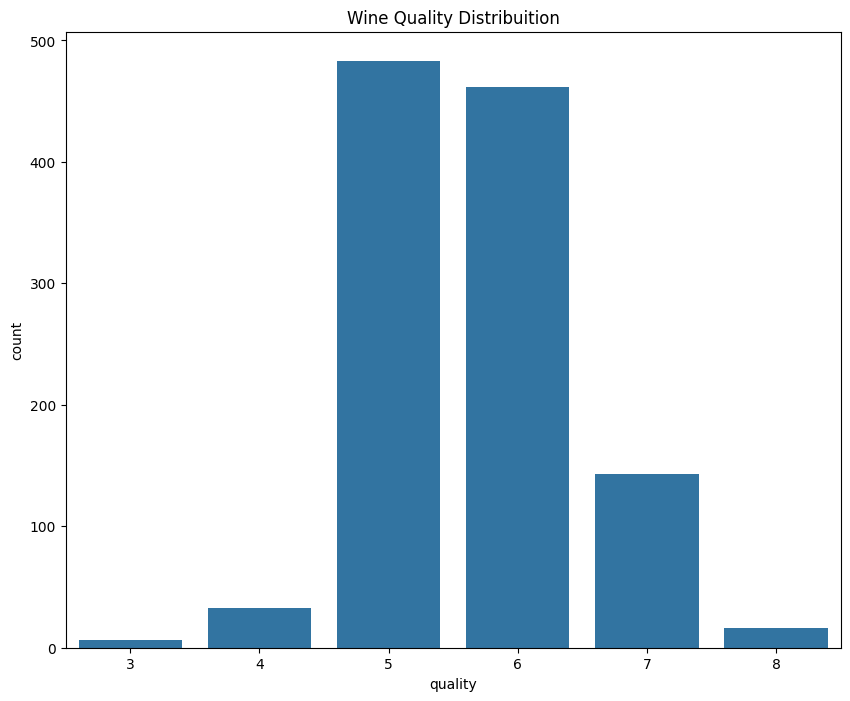

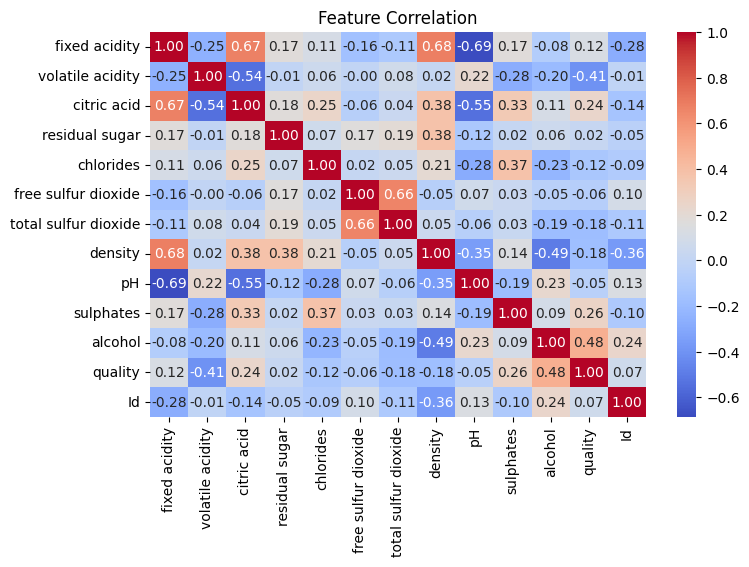

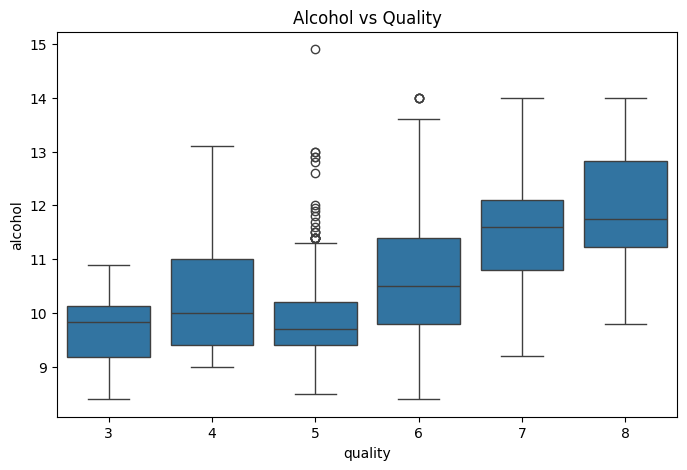

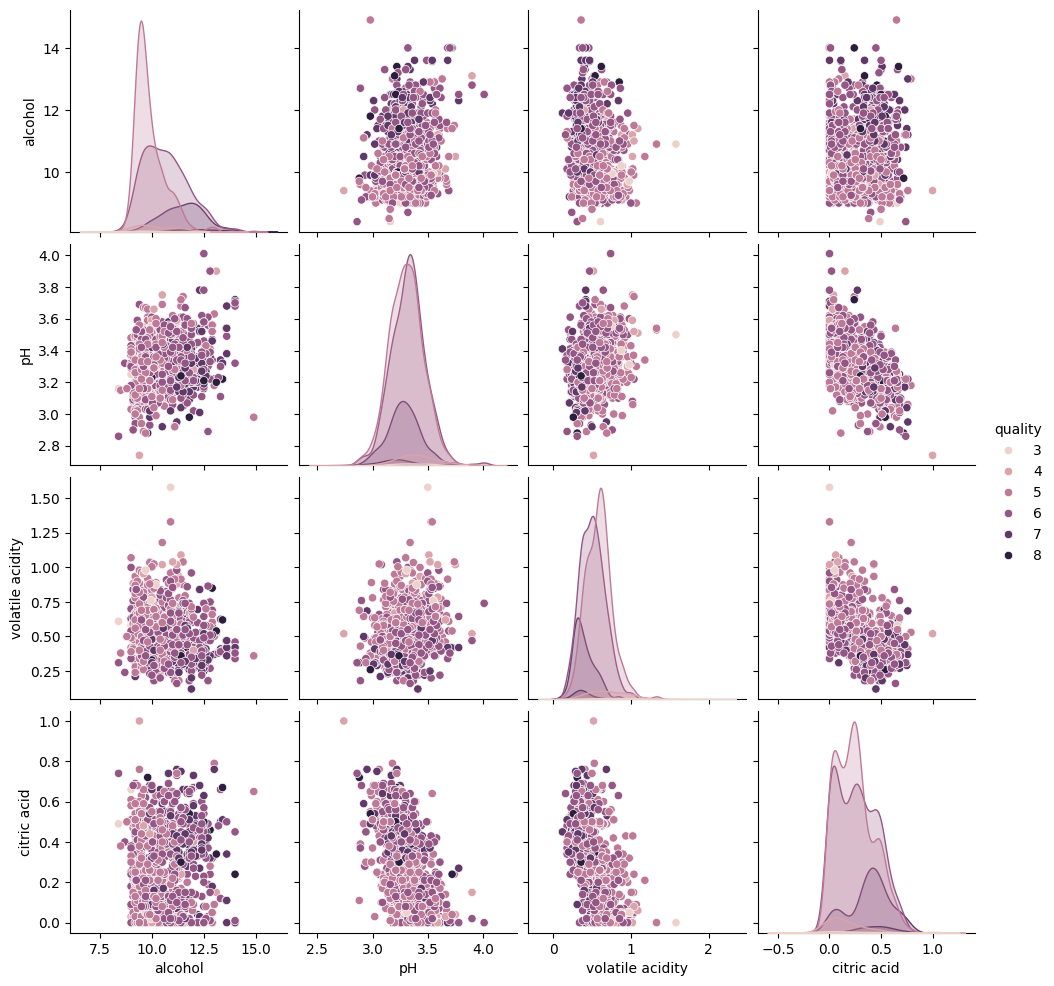

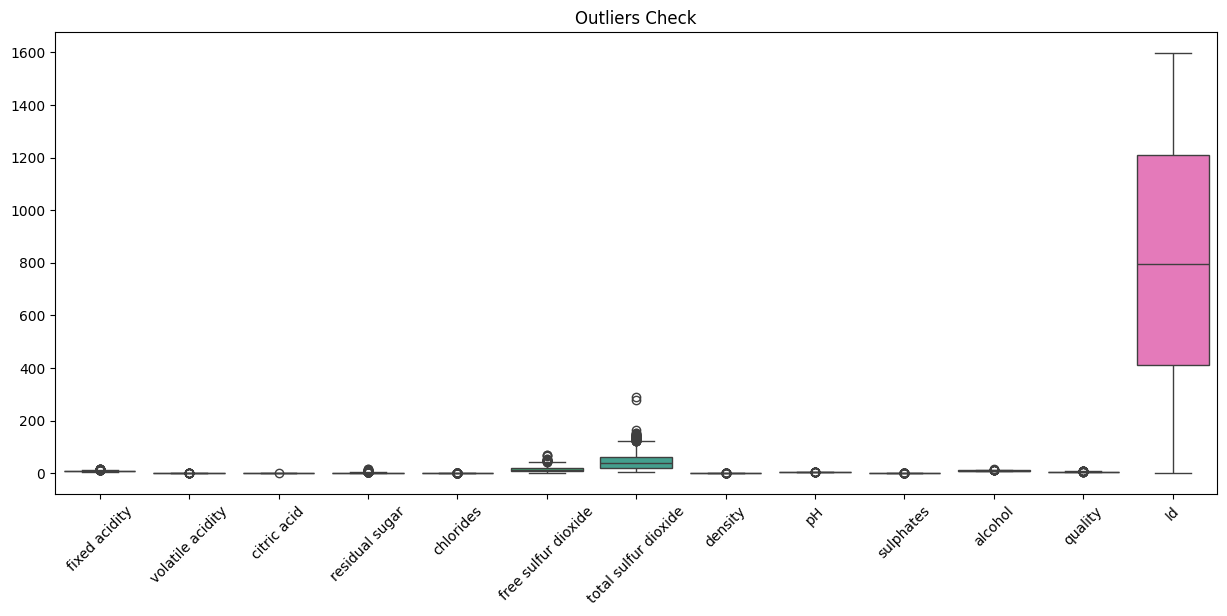

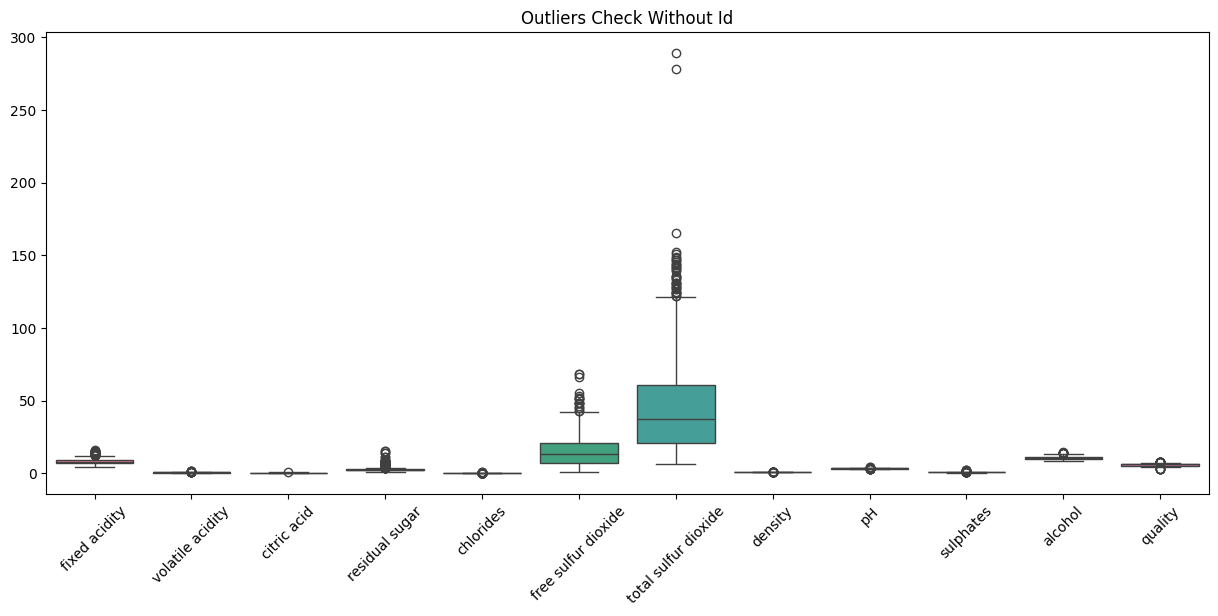

Before removing outliers: (1143, 12)
After removing outliers: (834, 12)
Rows removed: 309


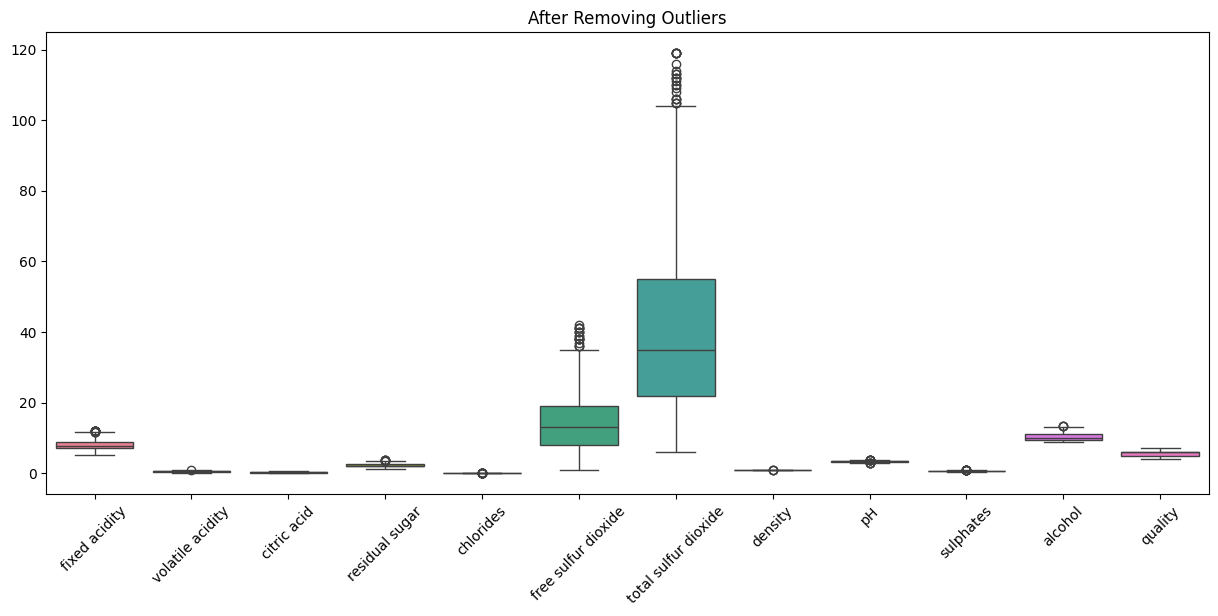

X_shape: (834, 11)
Y_shape: (834,)
Scaling DOne
Train size: (667, 11)
Test size: (167, 11)


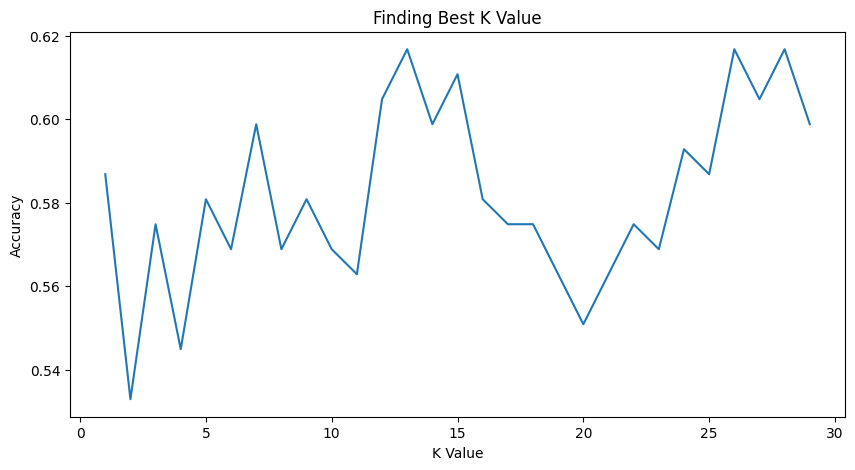

Best K value: 13
Best Accuracy: 0.62
Model trained! ✅
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         2
           5       0.60      0.83      0.70        65
           6       0.62      0.53      0.57        79
           7       0.44      0.19      0.27        21

    accuracy                           0.60       167
   macro avg       0.42      0.39      0.38       167
weighted avg       0.58      0.60      0.58       167



c:\Users\ranji\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ranji\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ranji\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [3]:
pipeline()
                 